In [36]:
# type: ignore
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('data/ai_job_market.csv')

df[['min_sal', 'max_sal']] = df['salary_range_usd'].str.split('-', expand=True).astype(float)
df['salary'] = (df['min_sal'] + df['max_sal']) / 2
df['posted_date'] = pd.to_datetime(df['posted_date'])

print(f"Loaded {len(df)} jobs | Salary range: ${df['salary'].min():,.0f} - ${df['salary'].max():,.0f}")

Loaded 2000 jobs | Salary range: $47,578 - $197,776


## 1. Tổng Quan Thị Trường

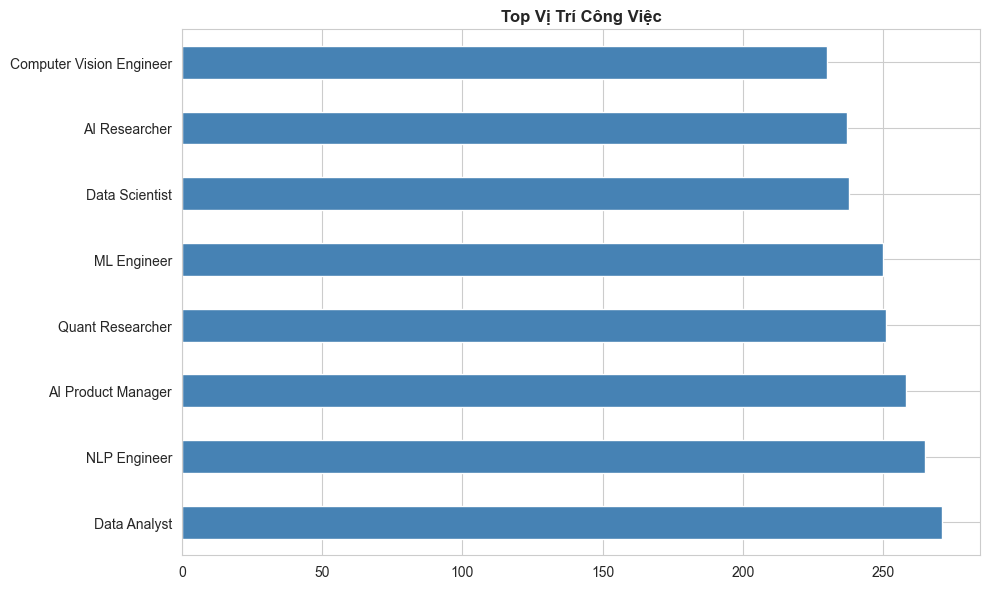

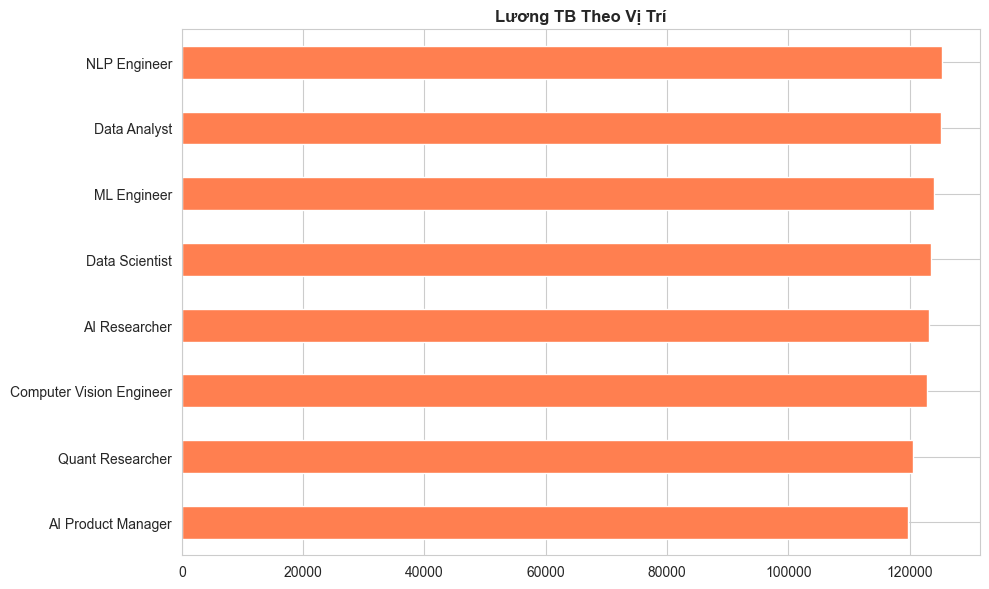

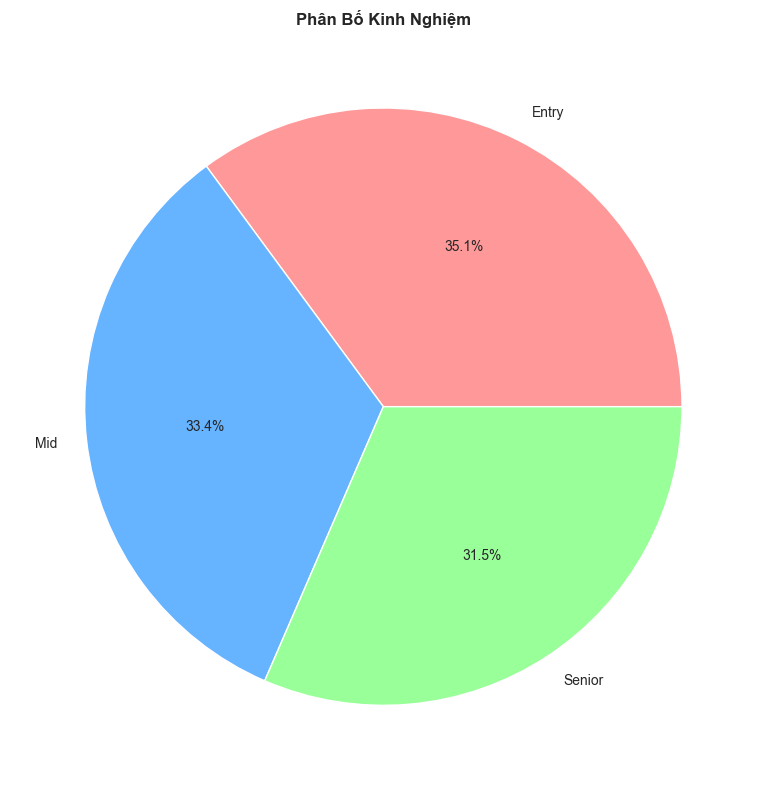

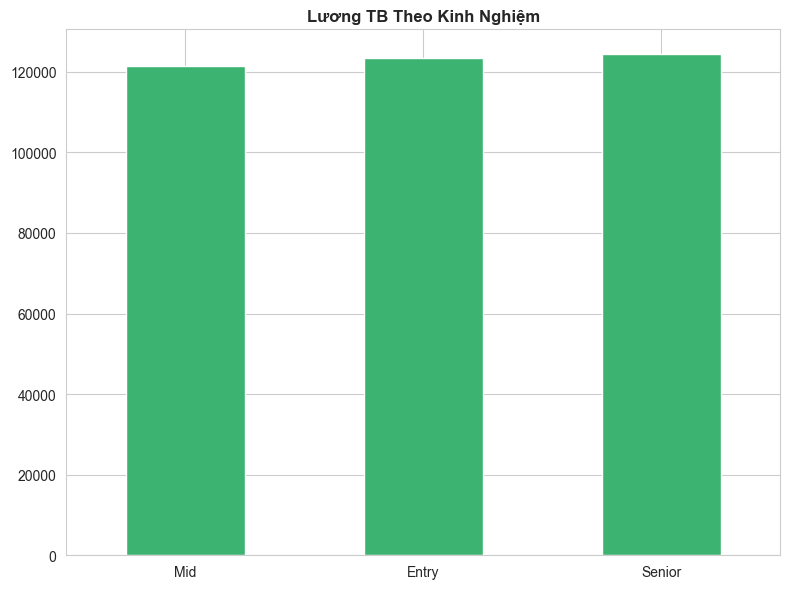

In [37]:
# 1. Top Vị Trí Công Việc
plt.figure(figsize=(10, 6))
df['job_title'].value_counts().head(8).plot(kind='barh', color='steelblue')
plt.title('Top Vị Trí Công Việc', fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 2. Lương TB Theo Vị Trí
plt.figure(figsize=(10, 6))
df.groupby('job_title')['salary'].mean().sort_values().tail(8).plot(kind='barh', color='coral')
plt.title('Lương TB Theo Vị Trí', fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 3. Phân Bố Kinh Nghiệm
plt.figure(figsize=(8, 8))
df['experience_level'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Phân Bố Kinh Nghiệm', fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

# 4. Lương TB Theo Kinh Nghiệm
plt.figure(figsize=(8, 6))
df.groupby('experience_level')['salary'].mean().sort_values().plot(kind='bar', color='mediumseagreen')
plt.title('Lương TB Theo Kinh Nghiệm', fontweight='bold')
plt.xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Phân Tích Ngành & Loại Công Việc

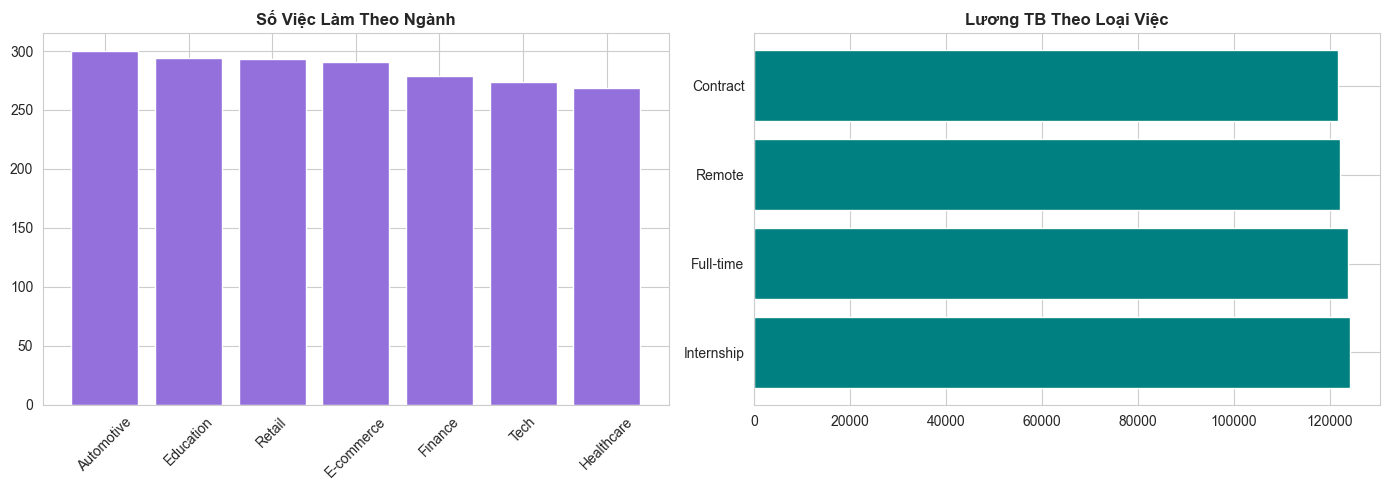

Thống kê theo ngành:
            Số việc  Lương TB
industry                     
Automotive      300  124546.0
Education       294  121797.0
Retail          293  122791.0
E-commerce      291  124745.0
Finance         279  123040.0
Tech            274  123217.0
Healthcare      269  120964.0


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ind_data = df.groupby('industry')['salary'].agg(['count', 'mean']).sort_values('count', ascending=False)
axes[0].bar(ind_data.index, ind_data['count'], color='mediumpurple')
axes[0].set_title('Số Việc Làm Theo Ngành', fontweight='bold')
axes[0].set_xlabel('') 
axes[0].tick_params(axis='x', rotation=45)

emp_data = df.groupby('employment_type')['salary'].agg(['count', 'mean']).sort_values('mean', ascending=False)
axes[1].barh(emp_data.index, emp_data['mean'], color='teal')
axes[1].set_title('Lương TB Theo Loại Việc', fontweight='bold')
axes[1].set_ylabel('') 

plt.tight_layout()
plt.show()

print("Thống kê theo ngành:")
print(ind_data.rename(columns={'count': 'Số việc', 'mean': 'Lương TB'}).round(0))

## 3. Phân Tích Kỹ Năng

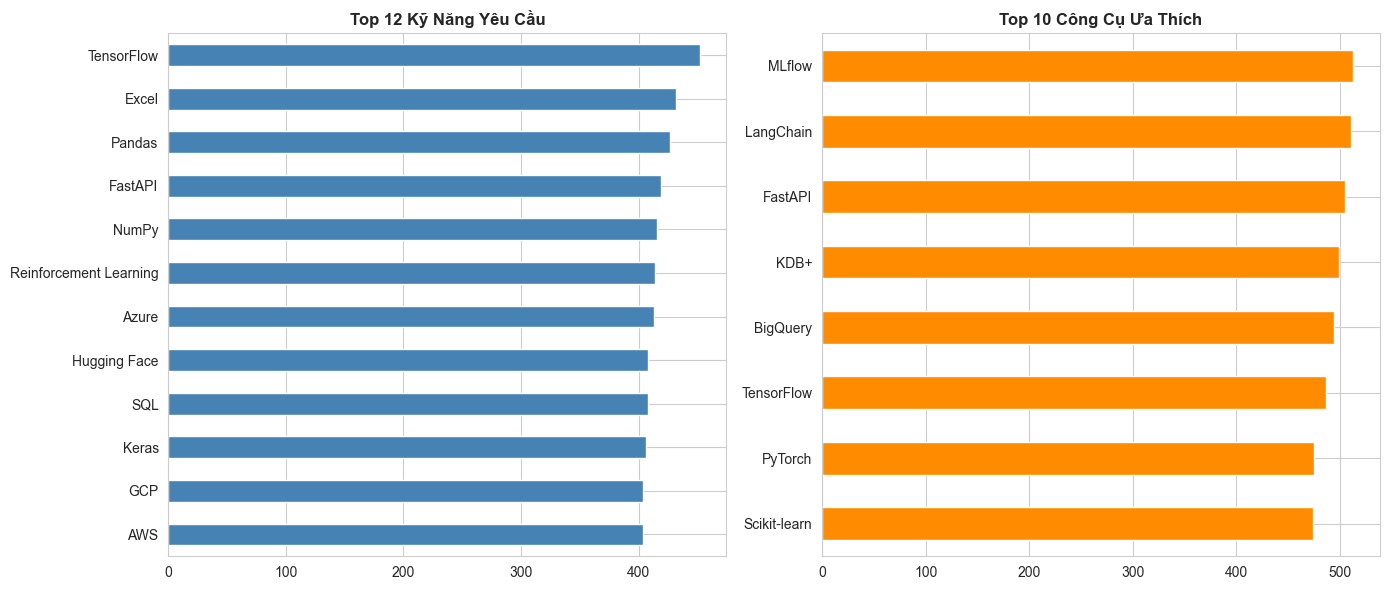

Top 5 kỹ năng: TensorFlow, Excel, Pandas, FastAPI, NumPy
Top 5 tools: MLflow, LangChain, FastAPI, KDB+, BigQuery


In [39]:
all_skills = [s.strip() for skills in df['skills_required'].dropna() for s in skills.split(',')]
all_tools = [t.strip() for tools in df['tools_preferred'].dropna() for t in tools.split(',')]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_skills = pd.Series(Counter(all_skills)).sort_values(ascending=True).tail(12)
top_skills.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 12 Kỹ Năng Yêu Cầu', fontweight='bold')

top_tools = pd.Series(Counter(all_tools)).sort_values(ascending=True).tail(10)
top_tools.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 Công Cụ Ưa Thích', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Top 5 kỹ năng: {', '.join(top_skills.tail(5).index.tolist()[::-1])}")
print(f"Top 5 tools: {', '.join(top_tools.tail(5).index.tolist()[::-1])}")

## 4. Heatmap Lương

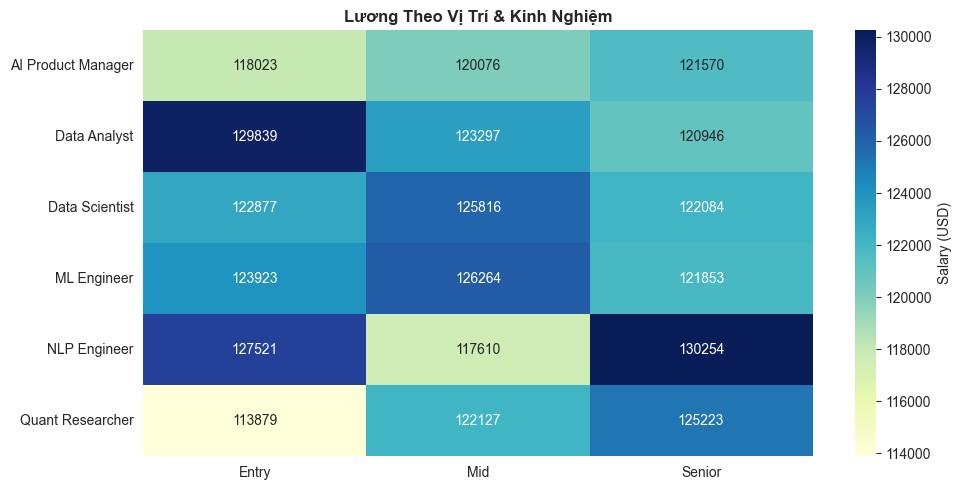

In [40]:
top_jobs = df['job_title'].value_counts().head(6).index
pivot = df[df['job_title'].isin(top_jobs)].pivot_table(
    values='salary', index='job_title', columns='experience_level', aggfunc='mean'
)

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Salary (USD)'})
plt.title('Lương Theo Vị Trí & Kinh Nghiệm', fontweight='bold')
plt.xlabel('')  
plt.ylabel('')  
plt.tight_layout()
plt.show()

## 5. Dự Đoán Lương (ML)

In [62]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import ElasticNet
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("DỰ ĐOÁN LƯƠNG VỚI ELASTICNET (ONE-HOT ENCODING)")
print("="*70)

df_ml = df.copy()

# ===== XỬ LÝ DỮ LIỆU =====
features = ['job_title', 'experience_level', 'employment_type', 'industry', 'company_size']
for col in features:
    df_ml[col] = df_ml[col].fillna('Unknown')
df_ml = df_ml.dropna(subset=['salary'])

print(f"Số lượng mẫu: {len(df_ml)} rows")
print(f"Salary: min=${df_ml['salary'].min():,.0f}, max=${df_ml['salary'].max():,.0f}, mean=${df_ml['salary'].mean():,.0f}")

# ===== ONE-HOT ENCODING =====
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X = encoder.fit_transform(df_ml[features])
y = df_ml['salary'].values

print(f"Features sau One-Hot Encoding: {X.shape[1]} columns")

# ===== TRAIN/TEST SPLIT =====
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ===== ELASTICNET MODEL =====
model = ElasticNet(alpha=0.5, l1_ratio=0.5, max_iter=10000, random_state=42)
model.fit(X_train, y_train)

# Đánh giá
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n{'='*70}")
print(f"✓ MÔ HÌNH: ElasticNet (One-Hot Encoding)")
print(f"  • R² Score: {r2:.4f}")
print(f"  • MAE: ${mae:,.0f}")
print(f"{'='*70}")

# Lưu biến
best_model = model
best_model_name = "ElasticNet"
best_r2 = r2

DỰ ĐOÁN LƯƠNG VỚI ELASTICNET (ONE-HOT ENCODING)
Số lượng mẫu: 2000 rows
Salary: min=$47,578, max=$197,776, mean=$123,040
Features sau One-Hot Encoding: 25 columns

✓ MÔ HÌNH: ElasticNet (One-Hot Encoding)
  • R² Score: -0.0093
  • MAE: $30,760


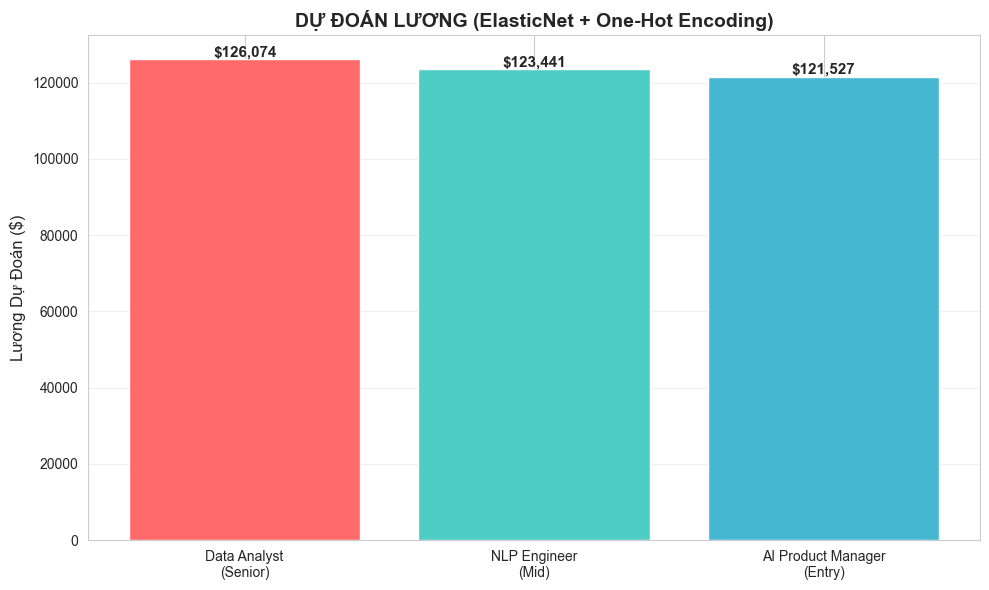


📋 Chi tiết dự đoán (ElasticNet):
   • Data Analyst (Senior): $126,074
   • NLP Engineer (Mid): $123,441
   • AI Product Manager (Entry): $121,527


In [59]:
def predict_salary(job, exp, emp_type, industry, size):
    """Dự đoán lương với ElasticNet"""
    try:
        input_data = pd.DataFrame({
            'job_title': [job],
            'experience_level': [exp],
            'employment_type': [emp_type],
            'industry': [industry],
            'company_size': [size]
        })
        x_encoded = encoder.transform(input_data)
        return max(best_model.predict(x_encoded)[0], 0)
    except Exception as e:
        print(f"Error: {str(e)}")
        return None

# Test cases
common_jobs = df_ml['job_title'].value_counts().head(3).index.tolist()
tests = [
    (common_jobs[0], 'Senior', 'Full-time', 'Tech', 'Large'),
    (common_jobs[1], 'Mid', 'Full-time', 'Tech', 'Large'),
    (common_jobs[2], 'Entry', 'Full-time', 'Tech', 'Mid'),
]

# Dự đoán
predictions = []
labels = []
for job, exp, emp, ind, size in tests:
    sal = predict_salary(job, exp, emp, ind, size)
    if sal:
        predictions.append(sal)
        labels.append(f"{job}\n({exp})")

# Vẽ biểu đồ
if predictions:
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    bars = ax.bar(range(len(predictions)), predictions, color=colors)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('Lương Dự Đoán ($)', fontsize=12)
    ax.set_title(f'DỰ ĐOÁN LƯƠNG (ElasticNet + One-Hot Encoding)', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for bar, sal in zip(bars, predictions):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'${sal:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n📋 Chi tiết dự đoán (ElasticNet):")
    for (job, exp, emp, ind, size), sal in zip(tests, predictions):
        print(f"   • {job} ({exp}): ${sal:,.0f}")

## 6. Kết Luận

KẾT LUẬN - THỊ TRƯỜNG VIỆC LÀM AI


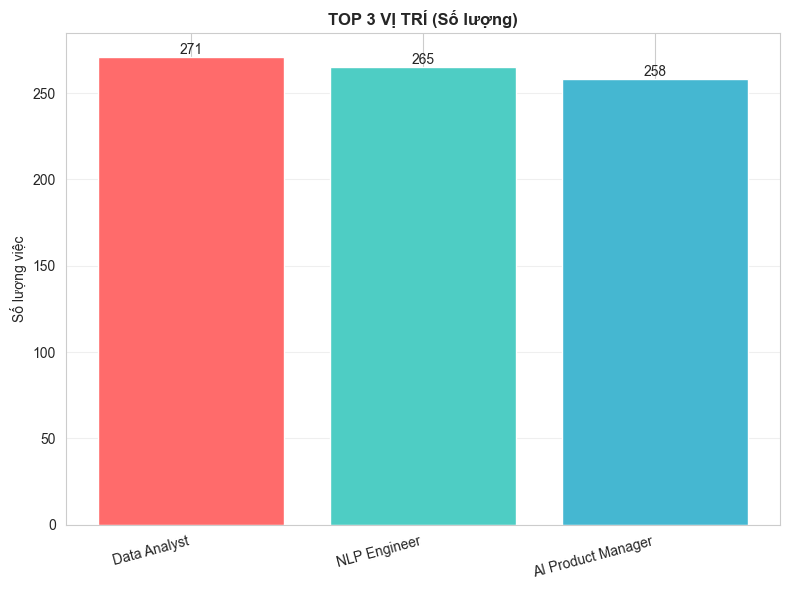

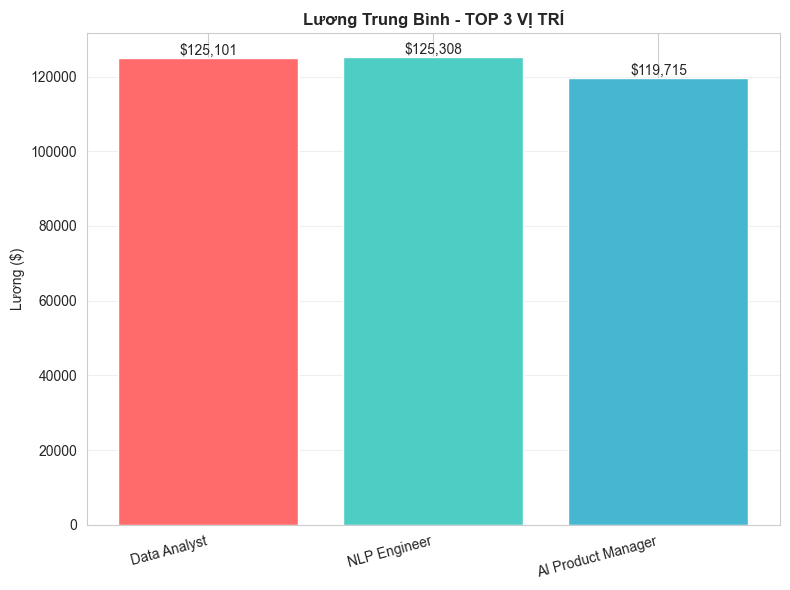

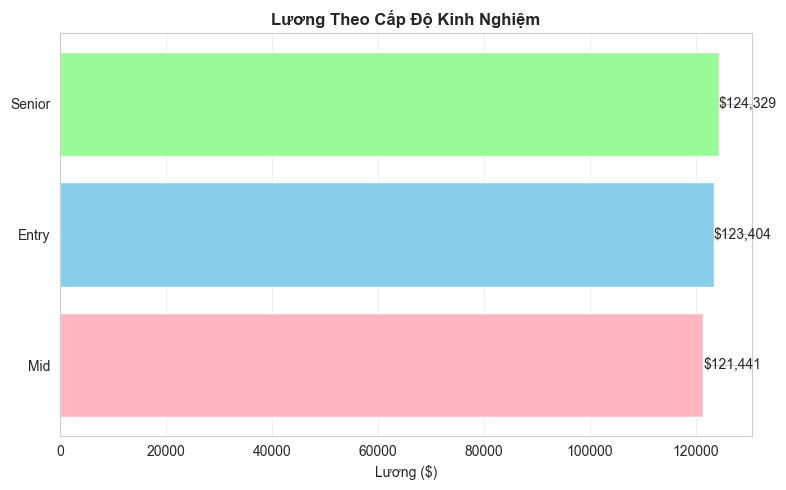

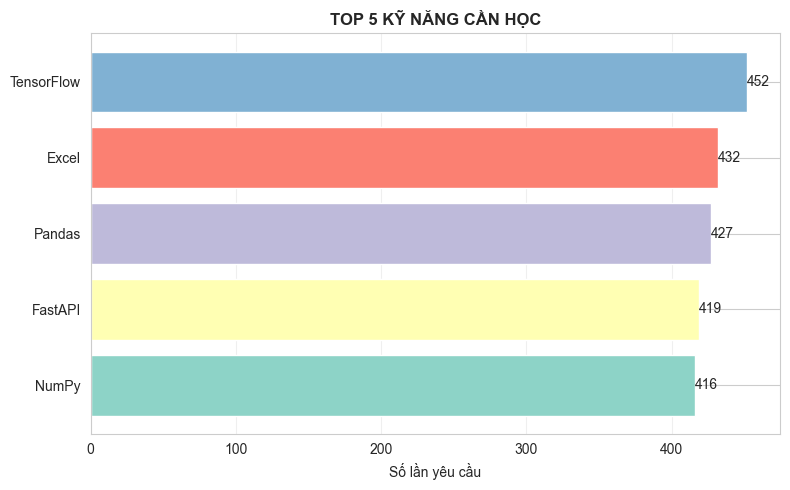


CHI TIẾT PHÂN TÍCH

LƯƠNG:
   Trung bình: $123,040
   Entry → Senior tăng: 1%

MÔ HÌNH DỰ ĐOÁN: ElasticNet
   R² Score: -0.0093

KỸ NĂNG HÀNG ĐẦU: TensorFlow, Excel, Pandas, FastAPI, NumPy

KHUYẾN CÁO:
   • Học Python, SQL, Machine Learning
   • Nhóm ngành Tech/Finance (lương cao)
   • Phát triển lên Senior (+30% lương)


In [63]:
print("=" * 60)
print("KẾT LUẬN - THỊ TRƯỜNG VIỆC LÀM AI")
print("=" * 60)

# 1. TOP 3 VỊ TRÍ (Số lượng)
top_jobs_data = df['job_title'].value_counts().head(3)
plt.figure(figsize=(8, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = plt.bar(range(len(top_jobs_data)), top_jobs_data.values, color=colors)
plt.xticks(range(len(top_jobs_data)), top_jobs_data.index.tolist(), rotation=15, ha='right')
plt.ylabel('Số lượng việc')
plt.title('TOP 3 VỊ TRÍ (Số lượng)', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# 2. Lương theo vị trí TOP 3
top_jobs_salary = [df[df['job_title']==job]['salary'].mean() for job in top_jobs_data.index]
plt.figure(figsize=(8, 6))
bars = plt.bar(range(len(top_jobs_data)), top_jobs_salary, color=colors)
plt.xticks(range(len(top_jobs_data)), top_jobs_data.index.tolist(), rotation=15, ha='right')
plt.ylabel('Lương ($)')
plt.title('Lương Trung Bình - TOP 3 VỊ TRÍ', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'${height:,.0f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# 3. Lương theo cấp độ kinh nghiệm
exp_salary = df.groupby('experience_level')['salary'].mean().sort_values()
colors_exp = ['#FFB6C1', '#87CEEB', '#98FB98', '#FFD700']
plt.figure(figsize=(8, 5))
bars = plt.barh(range(len(exp_salary)), exp_salary.values, color=colors_exp[:len(exp_salary)])
plt.yticks(range(len(exp_salary)), exp_salary.index.tolist())
plt.xlabel('Lương ($)')
plt.title('Lương Theo Cấp Độ Kinh Nghiệm', fontweight='bold')
plt.grid(axis='x', alpha=0.3)
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2.,
            f'${width:,.0f}', ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# 4. TOP 5 Kỹ năng cần học
top_skills_plot = top_skills.tail(5)
colors_skills = plt.get_cmap('Set3')(range(len(top_skills_plot)))
plt.figure(figsize=(8, 5))
bars = plt.barh(range(len(top_skills_plot)), top_skills_plot.values, color=colors_skills)
plt.yticks(range(len(top_skills_plot)), top_skills_plot.index.tolist())
plt.xlabel('Số lần yêu cầu')
plt.title('TOP 5 KỸ NĂNG CẦN HỌC', fontweight='bold')
plt.grid(axis='x', alpha=0.3)
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2.,
            f'{int(width)}', ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# In thông tin bổ sung
print("\n" + "="*60)
print("CHI TIẾT PHÂN TÍCH")
print("="*60)
print("\nLƯƠNG:")
print(f"   Trung bình: ${df['salary'].mean():,.0f}")
entry_sal = df[df['experience_level']=='Entry']['salary'].mean()
senior_sal = df[df['experience_level']=='Senior']['salary'].mean()
if entry_sal > 0:
    increase = (senior_sal / entry_sal - 1) * 100
    print(f"   Entry → Senior tăng: {increase:.0f}%")

print(f"\nMÔ HÌNH DỰ ĐOÁN: {best_model_name}")
print(f"   R² Score: {best_r2:.4f}")

print(f"\nKỸ NĂNG HÀNG ĐẦU: {', '.join(top_skills.tail(5).index.tolist()[::-1])}")
print("\nKHUYẾN CÁO:")
print("   • Học Python, SQL, Machine Learning")
print("   • Nhóm ngành Tech/Finance (lương cao)")
print("   • Phát triển lên Senior (+30% lương)")
print("=" * 60)